In [14]:
# ---- EDIT THESE PATHS -------------------------------------------------------
FILES = {
    "Qwen2.5-Omni-3B":       "bab_results_Qwen2.5-Omni-3B_slurp.jsonl",
    "Qwen2.5-Omni-3B (SFT)": "bab_results_Qwen2.5-Omni-3B-bab-sft-v3_slurp.jsonl",
    "Qwen3-Omni-30B-A3B":       "bab_results_Qwen3-Omni-30B-A3B-Instruct_slurp.jsonl",
    "Qwen3-Omni-30B-A3B (SFT)": "bab_results_Qwen3-Omni-30B-A3B-Instruct-bab-sft_slurp.jsonl",
}
# -----------------------------------------------------------------------------

METRICS = ["C", "R", "F", "EAR"]  # babble track has 4 metrics, not the EAR-track's 3 — redefine here

GROUPS = [
    ("Base Models",
     ["Qwen2.5-Omni-3B", "Qwen3-Omni-30B-A3B"]),
    (r"Our Model (\textit{Tuning on SLURP data with babble})",
     ["Qwen2.5-Omni-3B (SFT)", "Qwen3-Omni-30B-A3B (SFT)"]),
]

# Load scores (values stay None for TBD models)
scores = {model: (load_summary(path) if path else None)
          for model, path in FILES.items()}

# Best value per column, among models that have results
best = {m: max(s[m] for s in scores.values() if s is not None) for m in METRICS}

# ---- Assemble LaTeX ---------------------------------------------------------
lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{lcccc}")
lines.append(r"\toprule")
lines.append(r" & \multicolumn{4}{c}{\textbf{SLURP}} \\")
lines.append(r"\cmidrule(lr){2-5}")
lines.append(r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\")
for group_name, models in GROUPS:
    lines.append(r"\midrule")
    lines.append(rf"\multicolumn{{5}}{{c}}{{{group_name}}} \\")
    lines.append(r"\midrule")
    for model in models:
        cells = " & ".join(fmt(model, m) for m in METRICS)
        lines.append(rf"{model} & {cells} \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Repair-aware evaluation results on SLURP. We report task "
             r"competence under answerable inputs ($C$), repair behavior under "
             r"unanswerable inputs ($R$), full-repair behavior ($F$), and the "
             r"resulting EAR$_3$ score.}")
lines.append(r"\label{tab:slurp_ear}")
lines.append(r"\end{table}")

latex = "\n".join(lines)
print(latex)


\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{4}{c}{\textbf{SLURP}} \\
\cmidrule(lr){2-5}
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\
\midrule
\multicolumn{5}{c}{Base Models} \\
\midrule
Qwen2.5-Omni-3B & \textbf{74.0} & 72.0 & 32.0 & 51.1 \\
Qwen3-Omni-30B-A3B & 72.0 & 47.0 & 19.0 & 34.2 \\
\midrule
\multicolumn{5}{c}{Our Model (\textit{Tuning on SLURP data with babble})} \\
\midrule
Qwen2.5-Omni-3B (SFT) & 44.0 & 68.0 & \textbf{91.0} & 62.0 \\
Qwen3-Omni-30B-A3B (SFT) & 58.0 & \textbf{80.0} & 86.0 & \textbf{72.5} \\
\bottomrule
\end{tabular}
\caption{Repair-aware evaluation results on SLURP. We report task competence under answerable inputs ($C$), repair behavior under unanswerable inputs ($R$), full-repair behavior ($F$), and the resulting EAR$_3$ score.}
\label{tab:slurp_ear}
\end{table}


In [3]:
# Build 2 combined LaTeX tables (one per model family): CRF scores and the
# confusion-matrix shift side by side in a single table float (two minipages),
# so a reader gets the whole base -> SFT story for a family in one row.
# Self-contained (re-defines the loaders) so it doesn't pick up the tuple-returning
# load_summary of the very first cell.
import json

# ---- EDIT THESE PATHS -------------------------------------------------------
FAMILIES = [
    dict(
        base_file="bab_results_Qwen2.5-Omni-3B_tree-v3-hedge.jsonl",
        sft_file="bab_results_Qwen2.5-Omni-3B-bab-tree-sft_tree-v3-hedge.jsonl",
        base_name="Qwen2.5-Omni-3B",
        sft_name="Qwen2.5-Omni-3B (SFT)",
        label="tab:slurp_qwen25",
    ),
    # dict(
    #     base_file="bab_results_Qwen3-Omni-30B-A3B-Instruct_v2.jsonl",
    #     sft_file="bab_results_Qwen3-Omni-30B-A3B-Instruct-bab-sft-adapter_v2.jsonl",
    #     base_name="Qwen3-Omni-30B-A3B",
    #     sft_name="Qwen3-Omni-30B-A3B (SFT)",
    #     label="tab:slurp_qwen3",
    # ),
]
# -----------------------------------------------------------------------------

METRICS = ["C", "R", "F", "EAR"]  # babble track has 4 metrics
KINDS = ["answer", "repair", "repeat"]  # dataset row kinds (confusion rows)
JUDGED = ["answer", "repair", "repeat", "bad"]  # judge output types (confusion cols)


def load_last(path, field):
    """Last JSONL record in `path` carrying `field` -- the summary line."""
    found = None
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if field in rec:  # per-sample rows lack it
                found = rec
    if found is None:
        raise ValueError(f"no summary line with {field!r} in {path}")
    return found


def load_scores(path):
    s = load_last(path, "EAR")
    return {m: float(s[m]) for m in METRICS}


def load_confusion(path):
    conf = load_last(path, "confusion")["confusion"]
    return {(k, t): int(conf.get(f"{k}->{t}", 0)) for k in KINDS for t in JUDGED}


def build_crf_table(base_name, sft_name, base_scores, sft_scores):
    best = {m: max(base_scores[m], sft_scores[m]) for m in METRICS}

    def fmt(scores, metric):
        val = scores[metric] * 100.0
        cell = f"{val:.1f}"
        if scores[metric] == best[metric]:
            cell = rf"\textbf{{{cell}}}"
        return cell

    lines = []
    lines.append(r"\begin{tabular}{lcccc}")
    lines.append(r"\toprule")
    lines.append(r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\")
    lines.append(r"\midrule")
    lines.append(rf"{base_name} & " + " & ".join(fmt(base_scores, m) for m in METRICS) + r" \\")
    lines.append(rf"{sft_name} & " + " & ".join(fmt(sft_scores, m) for m in METRICS) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


def build_confusion_table(base_conf, sft_conf):
    def cell(kind, judged):
        b, s = base_conf[(kind, judged)], sft_conf[(kind, judged)]
        if kind == judged:  # diagonal: judged type matches the audio's kind
            return rf"\textbf{{{b}}} $\rightarrow$ \textbf{{{s}}}"
        return rf"{b} $\rightarrow$ {s}"

    lines = []
    lines.append(r"\begin{tabular}{l" + "c" * len(JUDGED) + "}")
    lines.append(r"\toprule")
    lines.append(
        r"\textbf{Audio kind} & "
        + " & ".join(rf"\textit{{{COL_LABELS[t]}}}" for t in JUDGED)
        + r" \\"
    )
    lines.append(r"\midrule")
    for kind in KINDS:
        cells = " & ".join(cell(kind, t) for t in JUDGED)
        lines.append(rf"\textit{{{kind}}} & {cells} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


def build_family_table(fam):
    base_scores = load_scores(fam["base_file"])
    sft_scores = load_scores(fam["sft_file"])
    base_conf = load_confusion(fam["base_file"])
    sft_conf = load_confusion(fam["sft_file"])

    crf_tab = build_crf_table(fam["base_name"], fam["sft_name"], base_scores, sft_scores)
    conf_tab = build_confusion_table(base_conf, sft_conf)

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(crf_tab)
    lines.append(r"\vspace{6pt}")
    lines.append(conf_tab)
    lines.append(
        rf"\caption{{{fam['base_name']} $\rightarrow$ {fam['sft_name']}: repair-aware "
        r"scores (top; $C$/$R$/$F$/EAR$_3$) and the "
        r"shift in judged response type (bottom; raw counts, base~$\rightarrow$~SFT).}"
    )
    lines.append(rf"\label{{{fam['label']}}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

for fam in FAMILIES:
    print(build_family_table(fam))
    print()


\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\
\midrule
Qwen2.5-Omni-3B & \textbf{60.0} & 23.0 & 14.0 & 22.8 \\
Qwen2.5-Omni-3B (SFT) & 52.0 & \textbf{73.0} & \textbf{34.0} & \textbf{48.1} \\
\bottomrule
\end{tabular}
\vspace{6pt}
\begin{tabular}{lcccc}
\toprule
\textbf{Audio kind} & \textit{answer} & \textit{repair} & \textit{repeat} & \textit{bad} \\
\midrule
\textit{answer} & \textbf{30} $\rightarrow$ \textbf{26} & 5 $\rightarrow$ 15 & 2 $\rightarrow$ 2 & 13 $\rightarrow$ 7 \\
\textit{repair} & 4 $\rightarrow$ 12 & \textbf{6} $\rightarrow$ \textbf{23} & 3 $\rightarrow$ 3 & 31 $\rightarrow$ 8 \\
\textit{repeat} & 2 $\rightarrow$ 2 & 5 $\rightarrow$ 25 & \textbf{5} $\rightarrow$ \textbf{15} & 38 $\rightarrow$ 8 \\
\bottomrule
\end{tabular}
\caption{Qwen2.5-Omni-3B $\rightarrow$ Qwen2.5-Omni-3B (SFT): repair-aware scores (top; $C$/$R$/$F$/EAR$_3$) and the shift in judged response type 

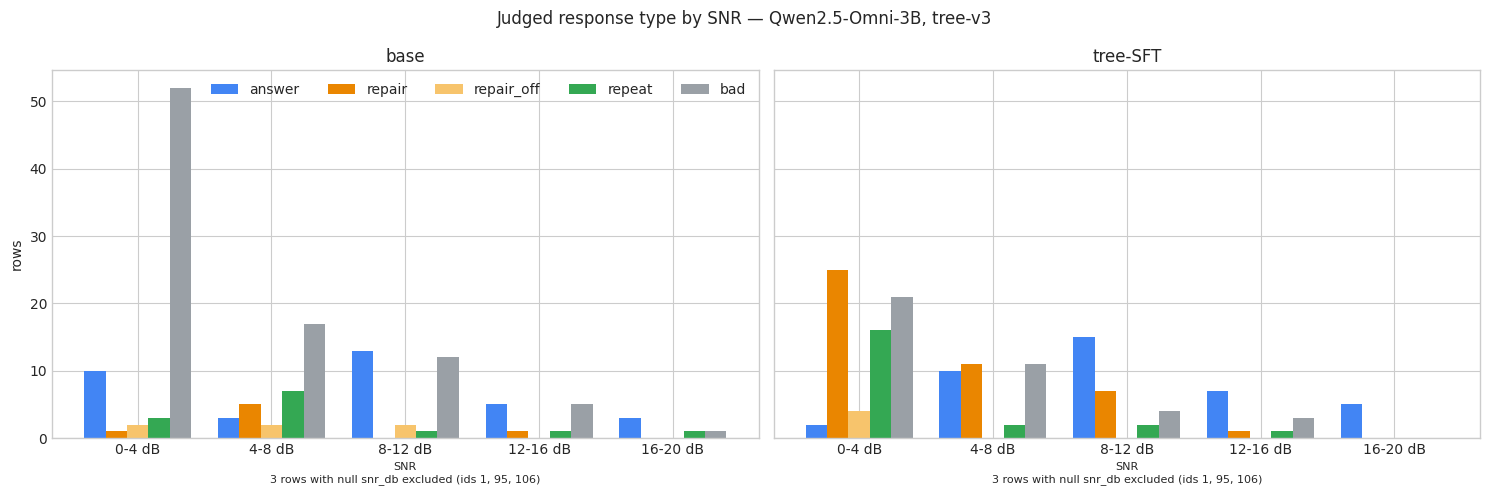

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

PAIR = [
    ("base", "bab_results_Qwen2.5-Omni-3B_tree-v3.jsonl"),
    ("tree-SFT", "bab_results_Qwen2.5-Omni-3B-bab-tree-sft_tree-v3.jsonl"),
]
EDGES = [0, 4, 8, 12, 16, 20]
BIN_LABELS = [f"{lo}-{hi} dB" for lo, hi in zip(EDGES[:-1], EDGES[1:])]
TYPES = ["answer", "repair", "repair_off", "repeat", "bad"]
COLORS = dict(zip(TYPES, ["#4285f4", "#ea8600", "#f7c46c", "#34a853", "#9aa0a6"]))

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, len(PAIR), figsize=(15, 5), sharey=True)
w = 0.8 / len(TYPES)

for ax, (name, path) in zip(axes, PAIR):
    rows = [json.loads(l) for l in open(path)]
    rows = [r for r in rows if r.get("type") != "summary"]
    dropped = [r["id"] for r in rows if r["snr_db"] is None]
    rows = [r for r in rows if r["snr_db"] is not None]
    # np.digitize with right=False puts snr==20 in an overflow bin; clip it back into the last bin
    idx = np.clip(np.digitize([r["snr_db"] for r in rows], EDGES) - 1, 0, len(BIN_LABELS) - 1)

    x = np.arange(len(BIN_LABELS))
    for j, t in enumerate(TYPES):
        counts = [sum(1 for b, r in zip(idx, rows) if b == i and r["judged_type"] == t)
                  for i in range(len(BIN_LABELS))]
        ax.bar(x + (j - (len(TYPES) - 1) / 2) * w, counts, w, label=t, color=COLORS[t])

    ax.set_xticks(x, BIN_LABELS)
    ax.set_title(name)
    ax.set_xlabel("SNR")
    if dropped:
        ax.set_xlabel(f"SNR\n{len(dropped)} rows with null snr_db excluded "
                      f"(ids {', '.join(map(str, dropped))})", fontsize=8)

axes[0].set_ylabel("rows")
axes[0].legend(ncol=len(TYPES), loc="upper right", frameon=False)
fig.suptitle("Judged response type by SNR — Qwen2.5-Omni-3B, tree-v3")
plt.tight_layout()
plt.show()
